# ⚡ Energy Consumption — Anomaly Detection Feasibility Analysis
---
**Goal**: Analyze the dataset to understand what types of anomalies exist naturally, what methods are practical, and what will actually deliver value.

**Dataset**: ~53K hourly electricity consumption readings (2016–2021), single column: `Electricity consumption (MWh)`

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_excel('/kaggle/input/datasets/atromixtheanalyzer/energy-consumption-dataset/Energy Consumption Dataset.xlsx')
df.columns = ['start', 'end', 'consumption']
df = df.sort_values('start').reset_index(drop=True)
df['start'] = pd.to_datetime(df['start'])
print(f"Shape: {df.shape}")
print(f"Date range: {df['start'].min()} → {df['start'].max()}")
print(f"Nulls: {df['consumption'].isnull().sum()}")
print(f"\nBasic stats:\n{df['consumption'].describe()}")

Shape: (52966, 3)
Date range: 2015-12-31 21:00:00 → 2021-12-31 20:00:00
Nulls: 0

Basic stats:
count    52966.000000
mean      9488.750519
std       1576.241673
min       5341.000000
25%       8322.000000
50%       9277.000000
75%      10602.000000
max      15105.000000
Name: consumption, dtype: float64


## 1. Time Series Overview & Visual Inspection

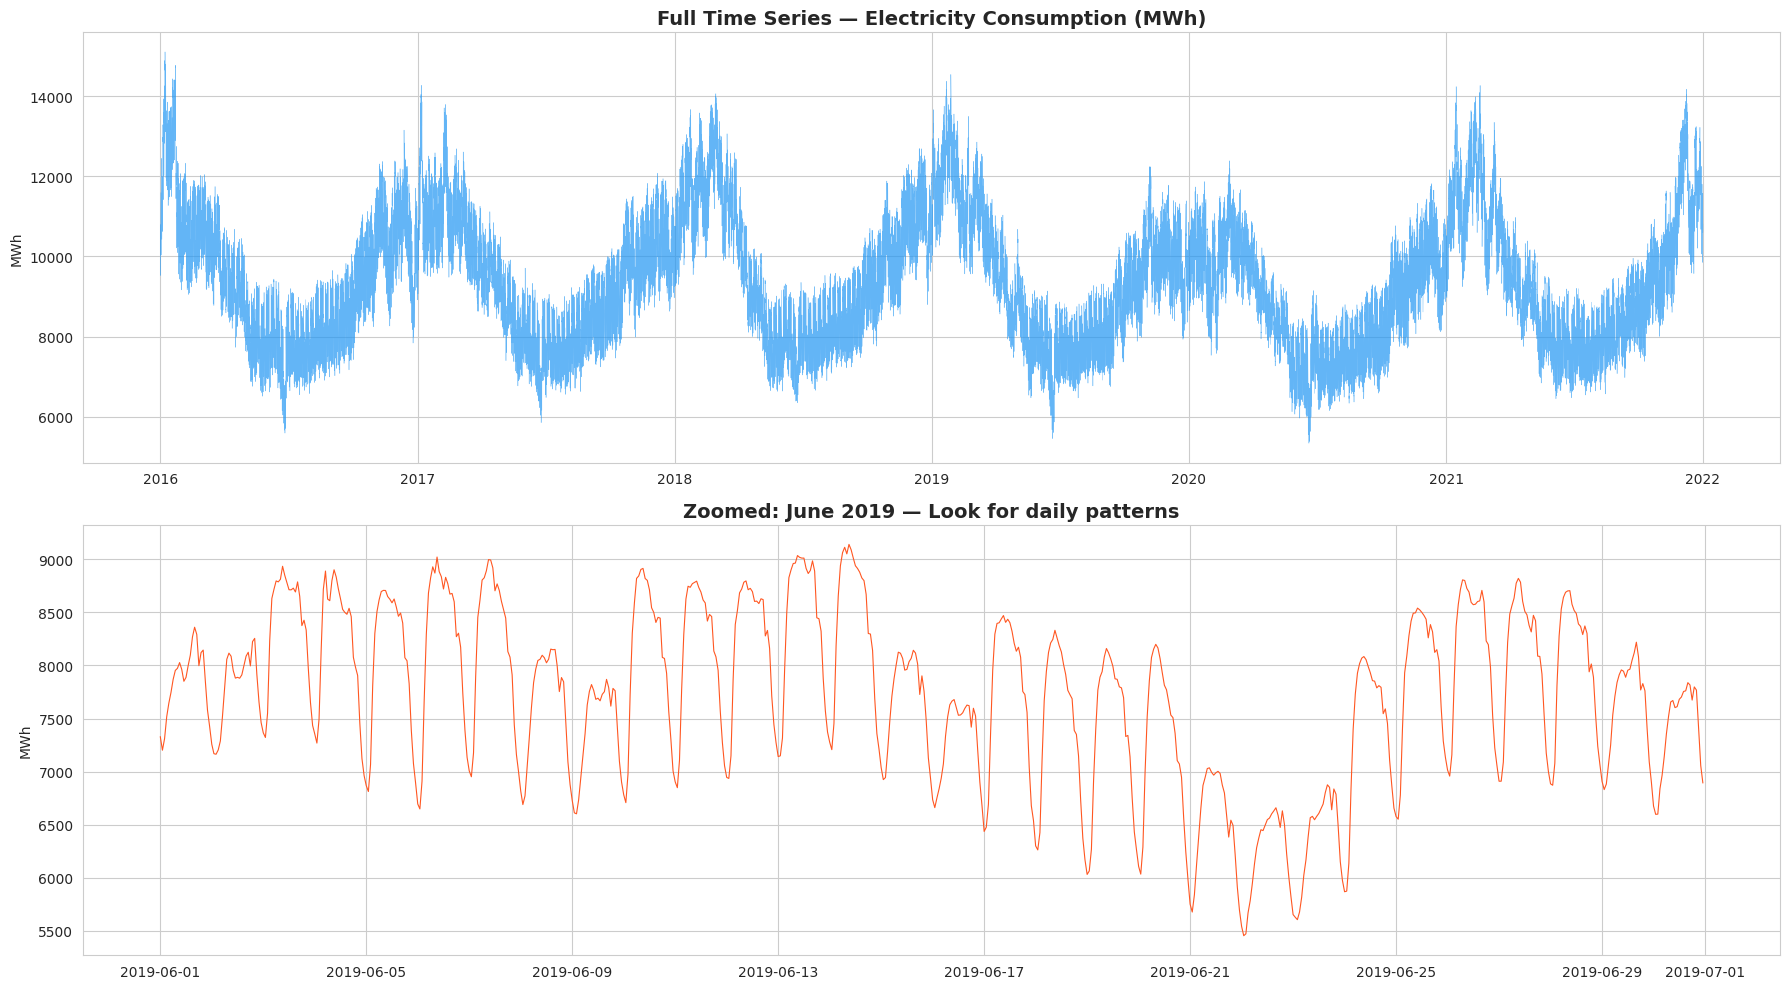

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Full series
axes[0].plot(df['start'], df['consumption'], linewidth=0.3, alpha=0.7, color='#2196F3')
axes[0].set_title('Full Time Series — Electricity Consumption (MWh)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MWh')

# Zoom into 1 month
mask = (df['start'] >= '2019-06-01') & (df['start'] < '2019-07-01')
axes[1].plot(df.loc[mask, 'start'], df.loc[mask, 'consumption'], linewidth=0.8, color='#FF5722')
axes[1].set_title('Zoomed: June 2019 — Look for daily patterns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MWh')
plt.tight_layout()
plt.show()

## 2. Temporal Feature Engineering

In [7]:
df['hour'] = df['start'].dt.hour
df['dow'] = df['start'].dt.dayofweek  # 0=Mon
df['month'] = df['start'].dt.month
df['year'] = df['start'].dt.year
df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)
df['day_name'] = df['start'].dt.day_name()

print("Features added: hour, dow, month, year, is_weekend")
print(f"Years present: {sorted(df['year'].unique())}")

Features added: hour, dow, month, year, is_weekend
Years present: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


## 3. Seasonality & Patterns (What is 'normal'?)

Understanding normal patterns is **critical** — anomalies are deviations from normal.

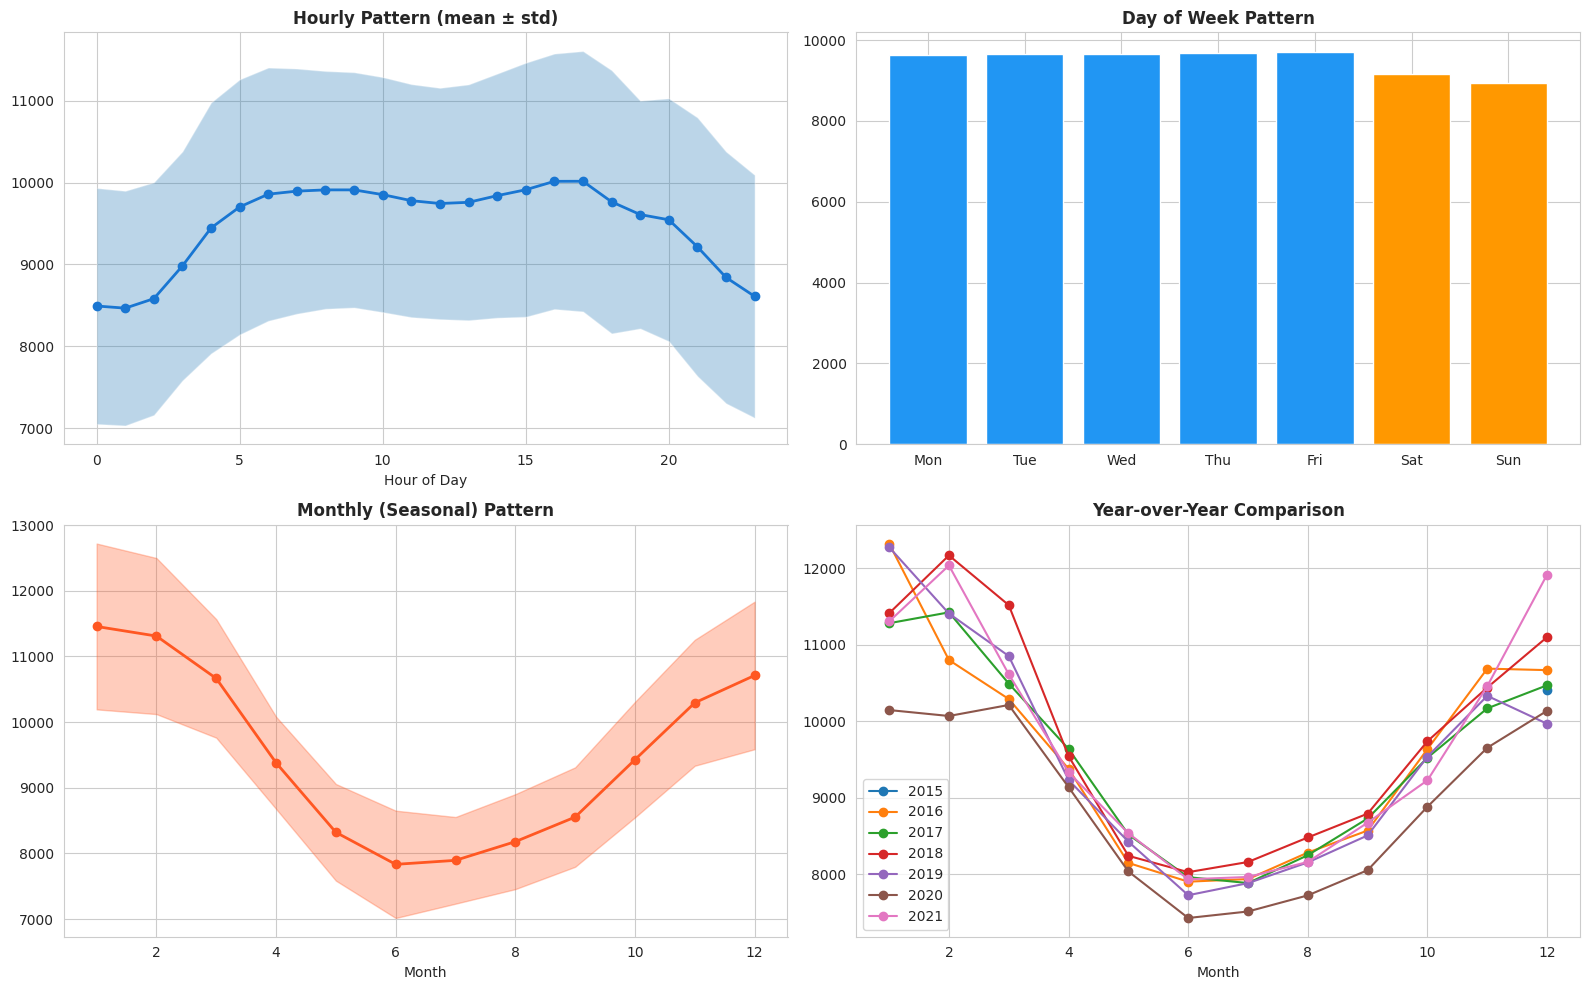

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Hourly pattern
hourly = df.groupby('hour')['consumption'].agg(['mean','std'])
axes[0,0].fill_between(hourly.index, hourly['mean']-hourly['std'], hourly['mean']+hourly['std'], alpha=0.3)
axes[0,0].plot(hourly.index, hourly['mean'], 'o-', linewidth=2, color='#1976D2')
axes[0,0].set_title('Hourly Pattern (mean ± std)', fontweight='bold')
axes[0,0].set_xlabel('Hour of Day')

# Day of week
dow_data = df.groupby('day_name')['consumption'].mean()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_data = dow_data.reindex(day_order)
colors = ['#2196F3']*5 + ['#FF9800']*2
axes[0,1].bar(range(7), dow_data.values, color=colors)
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels([d[:3] for d in day_order])
axes[0,1].set_title('Day of Week Pattern', fontweight='bold')

# Monthly pattern
monthly = df.groupby('month')['consumption'].agg(['mean','std'])
axes[1,0].fill_between(monthly.index, monthly['mean']-monthly['std'], monthly['mean']+monthly['std'], alpha=0.3, color='#FF5722')
axes[1,0].plot(monthly.index, monthly['mean'], 'o-', linewidth=2, color='#FF5722')
axes[1,0].set_title('Monthly (Seasonal) Pattern', fontweight='bold')
axes[1,0].set_xlabel('Month')

# Year-over-year
for yr in sorted(df['year'].unique()):
    sub = df[df['year']==yr].groupby('month')['consumption'].mean()
    axes[1,1].plot(sub.index, sub.values, 'o-', label=str(yr))
axes[1,1].set_title('Year-over-Year Comparison', fontweight='bold')
axes[1,1].legend()
axes[1,1].set_xlabel('Month')

plt.tight_layout()
plt.show()

## 4. Distribution Analysis — Are there natural outliers?

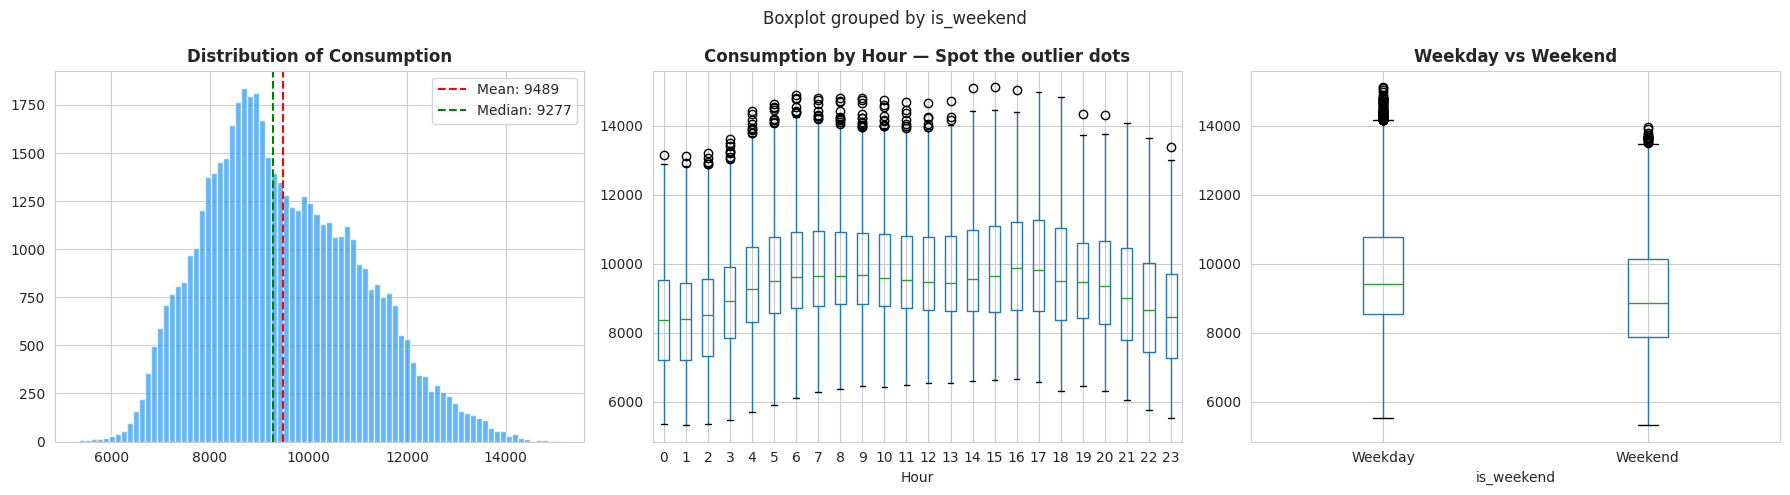

IQR bounds: [4902, 14022]
Global IQR outliers: 126 (0.24%)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['consumption'], bins=80, color='#2196F3', alpha=0.7, edgecolor='white')
axes[0].axvline(df['consumption'].mean(), color='red', linestyle='--', label=f"Mean: {df['consumption'].mean():.0f}")
axes[0].axvline(df['consumption'].median(), color='green', linestyle='--', label=f"Median: {df['consumption'].median():.0f}")
axes[0].set_title('Distribution of Consumption', fontweight='bold')
axes[0].legend()

# Box plot by hour
df.boxplot(column='consumption', by='hour', ax=axes[1])
axes[1].set_title('Consumption by Hour — Spot the outlier dots', fontweight='bold')
axes[1].set_xlabel('Hour')

# Box plot weekend vs weekday
df.boxplot(column='consumption', by='is_weekend', ax=axes[2])
axes[2].set_xticks([1, 2])
axes[2].set_xticklabels(['Weekday', 'Weekend'])
axes[2].set_title('Weekday vs Weekend', fontweight='bold')

plt.tight_layout()
plt.show()

# IQR outliers
Q1, Q3 = df['consumption'].quantile(0.25), df['consumption'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers_iqr = df[(df['consumption'] < lower) | (df['consumption'] > upper)]
print(f"IQR bounds: [{lower:.0f}, {upper:.0f}]")
print(f"Global IQR outliers: {len(outliers_iqr)} ({100*len(outliers_iqr)/len(df):.2f}%)")

## 5. Timestamp Irregularities — Gaps & Data Quality

In [10]:
time_diffs = df['start'].diff()
non_hourly = time_diffs[time_diffs != pd.Timedelta(hours=1)].dropna()

print(f"Total non-hourly gaps: {len(non_hourly)}")
print(f"\nGap distribution:")
print(non_hourly.value_counts().head(15))

# Large gaps (>2 hours)
large_gaps = time_diffs[time_diffs > pd.Timedelta(hours=2)].dropna()
print(f"\nGaps > 2 hours: {len(large_gaps)}")
if len(large_gaps) > 0:
    for idx in large_gaps.index[:10]:
        print(f"  {df.loc[idx-1,'start']} → {df.loc[idx,'start']} (gap: {large_gaps[idx]})")

Total non-hourly gaps: 1247

Gap distribution:
start
0 days 00:55:00    513
0 days 00:05:00    377
0 days 01:05:00    156
0 days 00:50:00     32
0 days 00:10:00     28
0 days 00:35:00     23
0 days 02:00:00     21
0 days 00:25:00     18
0 days 00:30:00     10
0 days 00:45:00      9
0 days 00:15:00      8
0 days 01:10:00      7
0 days 00:20:00      6
0 days 00:40:00      4
0 days 01:30:00      4
Name: count, dtype: int64

Gaps > 2 hours: 13
  2016-01-11 11:00:00 → 2016-01-11 17:30:00 (gap: 0 days 06:30:00)
  2016-04-04 15:00:00 → 2016-04-05 06:00:00 (gap: 0 days 15:00:00)
  2016-05-10 05:00:00 → 2016-05-10 08:00:00 (gap: 0 days 03:00:00)
  2016-06-25 09:25:00 → 2016-06-25 12:00:00 (gap: 0 days 02:35:00)
  2017-04-02 05:00:00 → 2017-04-02 11:00:00 (gap: 0 days 06:00:00)
  2017-04-25 13:00:00 → 2017-04-25 19:00:00 (gap: 0 days 06:00:00)
  2017-06-20 06:00:00 → 2017-06-20 08:05:00 (gap: 0 days 02:05:00)
  2019-04-21 07:00:00 → 2019-04-21 13:00:00 (gap: 0 days 06:00:00)
  2019-05-04 06:00:0

## 6. Method 1: Z-Score Anomaly Detection
Simple, fast, interpretable. Detects **point anomalies** (extreme values).

Z > 2: 1967 anomalies (3.71%)
Z > 2.5: 525 anomalies (0.99%)
Z > 3: 69 anomalies (0.13%)
Z > 3.5: 3 anomalies (0.01%)

Using Z > 3: 69 anomalies


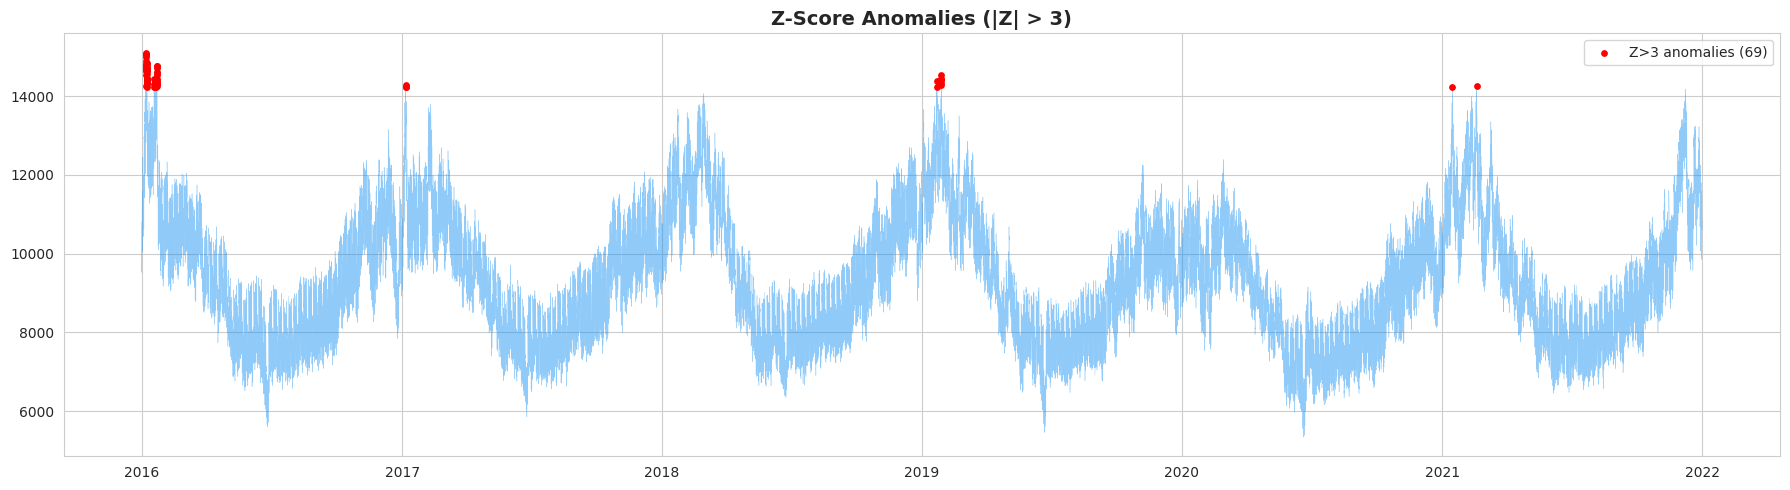

In [11]:
z_scores = np.abs(stats.zscore(df['consumption']))
df['zscore'] = z_scores

for thresh in [2, 2.5, 3, 3.5]:
    count = (z_scores > thresh).sum()
    print(f"Z > {thresh}: {count} anomalies ({100*count/len(df):.2f}%)")

# Use Z > 3 as threshold
anomalies_z = df[df['zscore'] > 3].copy()
print(f"\nUsing Z > 3: {len(anomalies_z)} anomalies")

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df['start'], df['consumption'], linewidth=0.3, alpha=0.5, color='#2196F3')
ax.scatter(anomalies_z['start'], anomalies_z['consumption'], c='red', s=15, zorder=5, label=f'Z>3 anomalies ({len(anomalies_z)})')
ax.set_title('Z-Score Anomalies (|Z| > 3)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Method 2: Context-Aware Detection (Hourly Z-Scores)
This is the **key insight** — a value is only anomalous relative to its context (hour, day, season).

Context-aware anomalies (Z>3 within group): 203

Only global Z-score: 69
Only context-aware:  203
Both methods:        0

→ Context-aware finds 203 anomalies that global Z-score misses!


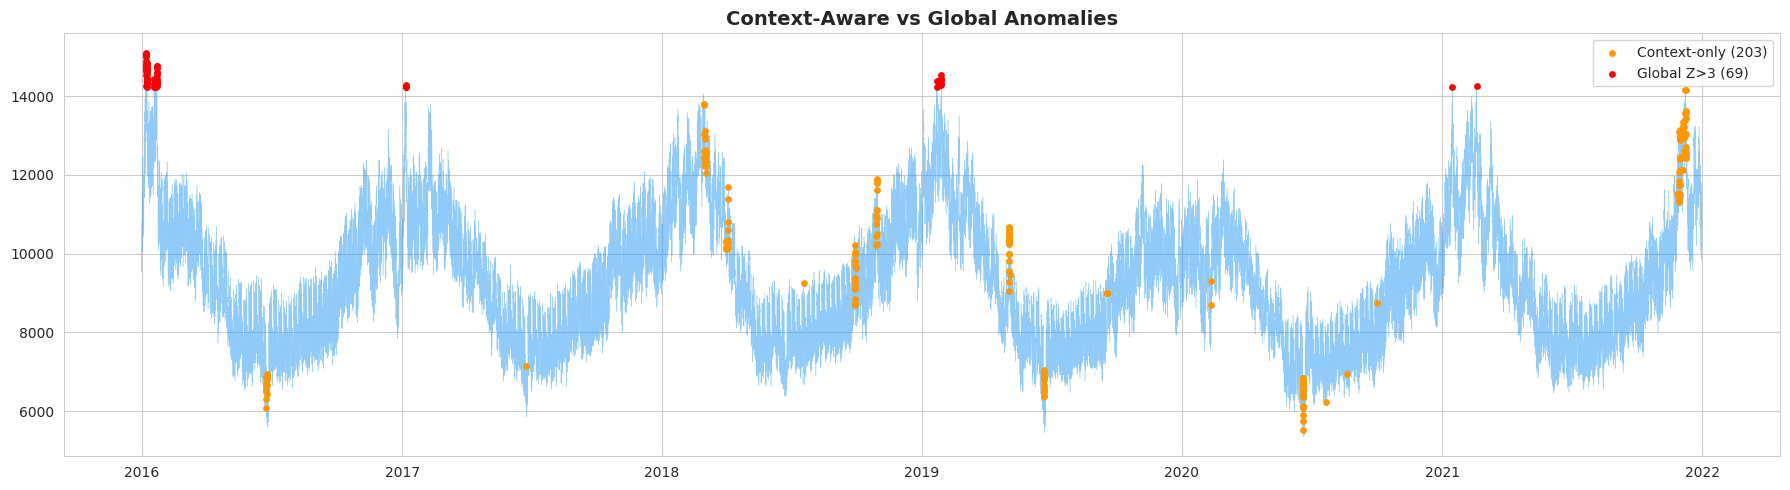

In [12]:
# Compute z-score within each (hour, is_weekend, month) group
df['ctx_zscore'] = df.groupby(['hour', 'is_weekend', 'month'])['consumption'].transform(
    lambda x: np.abs(stats.zscore(x))
)

anomalies_ctx = df[df['ctx_zscore'] > 3].copy()
print(f"Context-aware anomalies (Z>3 within group): {len(anomalies_ctx)}")

# Compare: how many are ONLY caught by context-aware?
only_global = set(anomalies_z.index) - set(anomalies_ctx.index)
only_ctx = set(anomalies_ctx.index) - set(anomalies_z.index)
both = set(anomalies_z.index) & set(anomalies_ctx.index)
print(f"\nOnly global Z-score: {len(only_global)}")
print(f"Only context-aware:  {len(only_ctx)}")  
print(f"Both methods:        {len(both)}")
print(f"\n→ Context-aware finds {len(only_ctx)} anomalies that global Z-score misses!")

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df['start'], df['consumption'], linewidth=0.3, alpha=0.5, color='#2196F3')
only_ctx_df = df.loc[list(only_ctx)]
ax.scatter(only_ctx_df['start'], only_ctx_df['consumption'], c='#FF9800', s=15, zorder=5, label=f'Context-only ({len(only_ctx)})')
ax.scatter(anomalies_z['start'], anomalies_z['consumption'], c='red', s=15, zorder=5, label=f'Global Z>3 ({len(anomalies_z)})')
ax.set_title('Context-Aware vs Global Anomalies', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Method 3: Isolation Forest
Unsupervised ML method — good for finding anomalies in multi-dimensional feature space.

contamination=0.005: 265 anomalies (0.50%)
contamination=0.01: 530 anomalies (1.00%)
contamination=0.02: 1060 anomalies (2.00%)
contamination=0.05: 2649 anomalies (5.00%)

Isolation Forest (1%): 530 anomalies


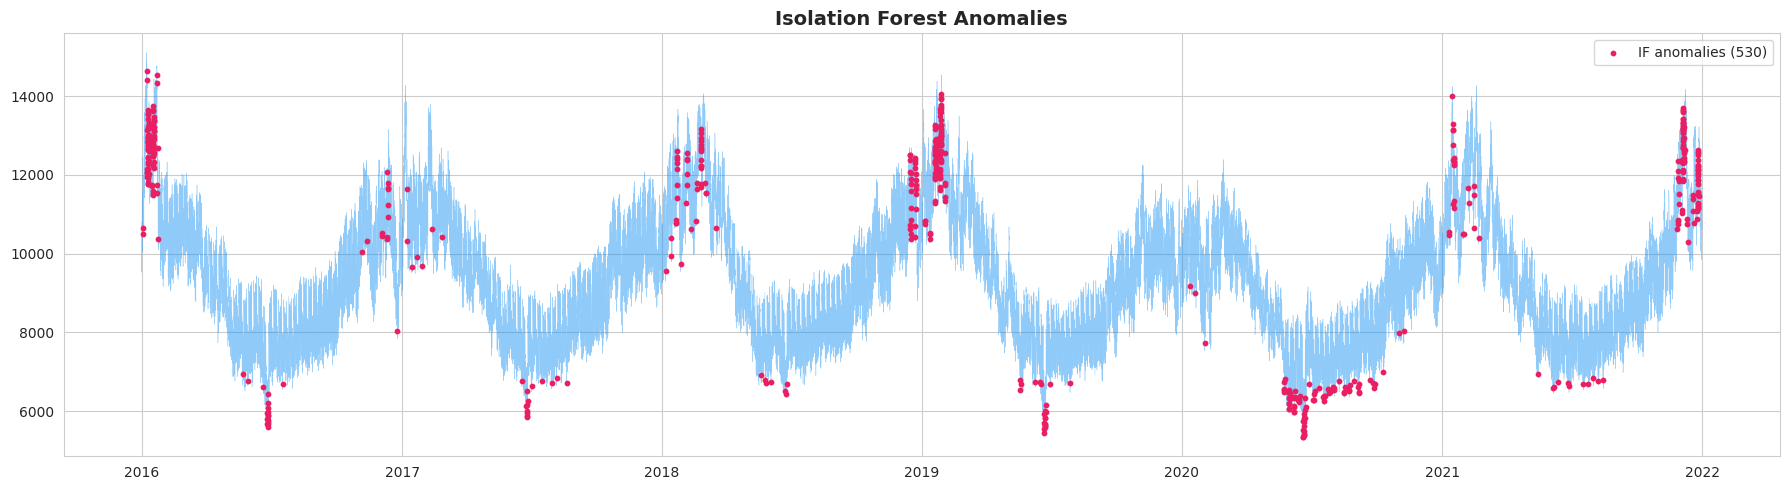

In [13]:
features = ['consumption', 'hour', 'dow', 'month', 'is_weekend']
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for contamination in [0.005, 0.01, 0.02, 0.05]:
    iso = IsolationForest(contamination=contamination, random_state=42, n_jobs=-1)
    preds = iso.fit_predict(X_scaled)
    n_anom = (preds == -1).sum()
    print(f"contamination={contamination}: {n_anom} anomalies ({100*n_anom/len(df):.2f}%)")

# Use 1% contamination
iso_model = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
df['iso_pred'] = iso_model.fit_predict(X_scaled)
df['iso_score'] = iso_model.decision_function(X_scaled)

anomalies_iso = df[df['iso_pred'] == -1]
print(f"\nIsolation Forest (1%): {len(anomalies_iso)} anomalies")

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df['start'], df['consumption'], linewidth=0.3, alpha=0.5, color='#2196F3')
ax.scatter(anomalies_iso['start'], anomalies_iso['consumption'], c='#E91E63', s=10, zorder=5, label=f'IF anomalies ({len(anomalies_iso)})')
ax.set_title('Isolation Forest Anomalies', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Method 4: Rolling Statistics (Trend Anomalies)
Detect gradual shifts and sudden changes in the moving average.

Rolling window anomalies (Z>3): 0


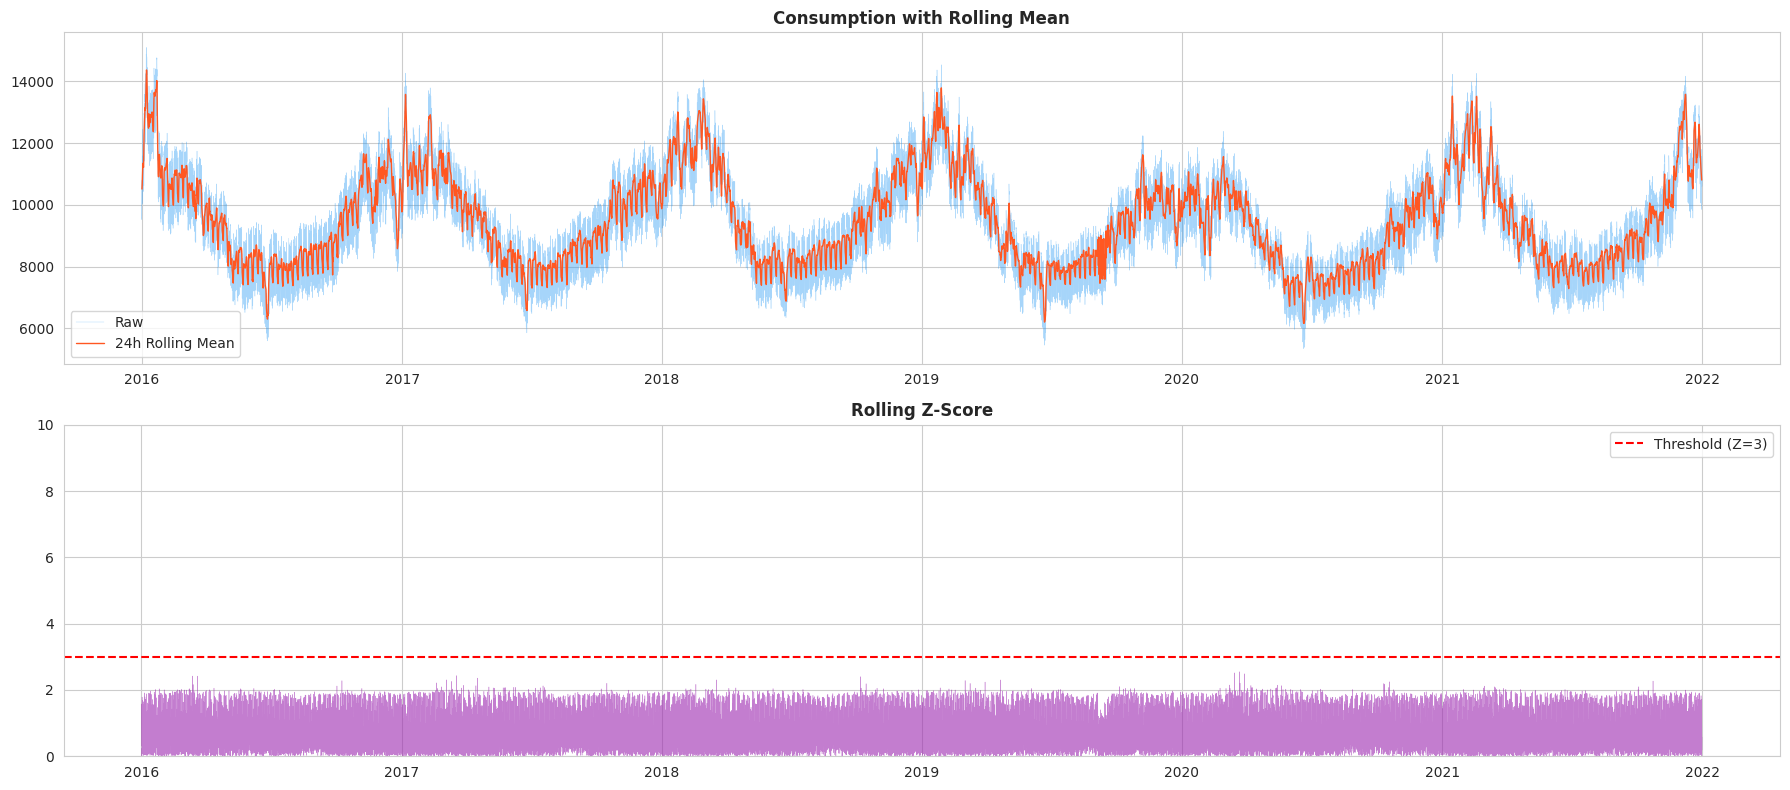

In [14]:
window = 24  # 24-hour rolling window
df['rolling_mean'] = df['consumption'].rolling(window, center=True).mean()
df['rolling_std'] = df['consumption'].rolling(window, center=True).std()
df['deviation'] = np.abs(df['consumption'] - df['rolling_mean'])
df['rolling_zscore'] = df['deviation'] / df['rolling_std']

anomalies_roll = df[df['rolling_zscore'] > 3].dropna(subset=['rolling_zscore'])
print(f"Rolling window anomalies (Z>3): {len(anomalies_roll)}")

fig, axes = plt.subplots(2, 1, figsize=(18, 8))

axes[0].plot(df['start'], df['consumption'], linewidth=0.3, alpha=0.4, color='#2196F3', label='Raw')
axes[0].plot(df['start'], df['rolling_mean'], linewidth=1, color='#FF5722', label='24h Rolling Mean')
axes[0].set_title('Consumption with Rolling Mean', fontweight='bold')
axes[0].legend()

axes[1].plot(df['start'], df['rolling_zscore'], linewidth=0.3, color='#9C27B0', alpha=0.6)
axes[1].axhline(y=3, color='red', linestyle='--', label='Threshold (Z=3)')
axes[1].set_title('Rolling Z-Score', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

## 10. Method Comparison — Overlap & Agreement
Which methods agree? This tells us which anomalies are **most reliable**.

=== Agreement Counts ===
anom_score
0    52182
1      766
2       18
Name: count, dtype: int64

High-confidence anomalies (2+ methods): 18
  - Breakdown by hour: {3: np.int64(1), 4: np.int64(2), 5: np.int64(2), 8: np.int64(1), 9: np.int64(1), 10: np.int64(1), 11: np.int64(1), 12: np.int64(1), 13: np.int64(1), 21: np.int64(2)}
  - Breakdown by month: {1: np.int64(4), 6: np.int64(2), 11: np.int64(1), 12: np.int64(11)}
  - Weekend share: 61.1%


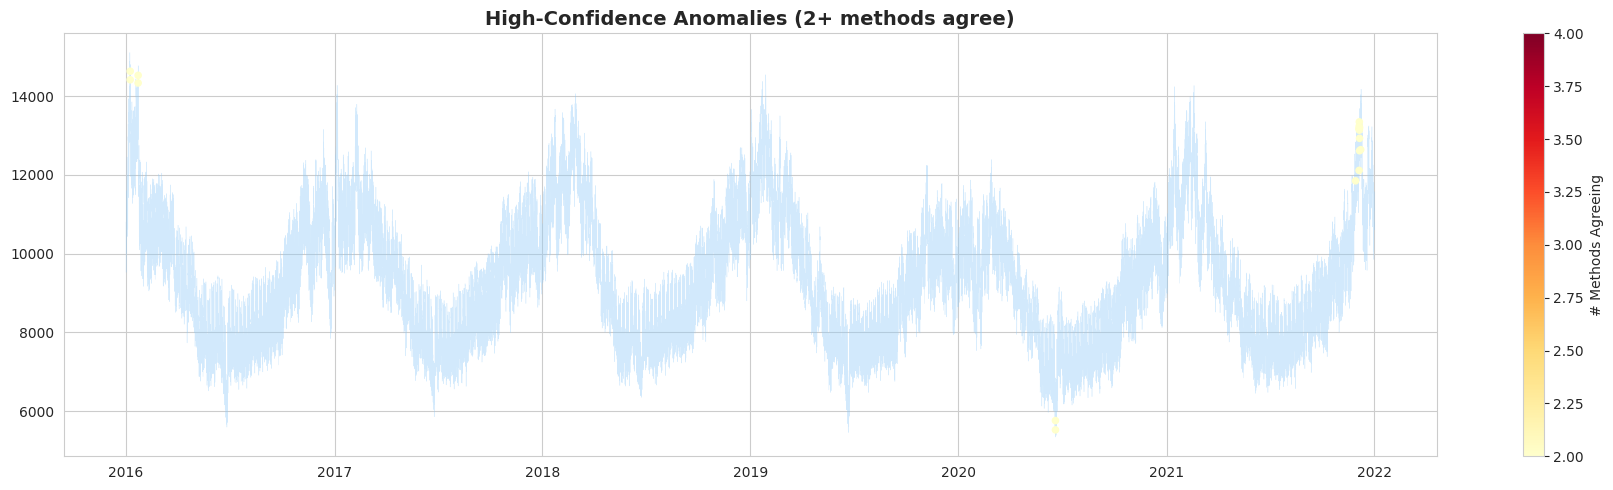

In [15]:
df['anom_global_z'] = (df['zscore'] > 3).astype(int)
df['anom_ctx_z'] = (df['ctx_zscore'] > 3).astype(int)
df['anom_iso'] = (df['iso_pred'] == -1).astype(int)
df['anom_rolling'] = (df['rolling_zscore'] > 3).astype(int).fillna(0).astype(int)

df['anom_score'] = df['anom_global_z'] + df['anom_ctx_z'] + df['anom_iso'] + df['anom_rolling']

print("=== Agreement Counts ===")
print(df['anom_score'].value_counts().sort_index())
print()

# High-confidence anomalies (2+ methods agree)
high_conf = df[df['anom_score'] >= 2]
print(f"High-confidence anomalies (2+ methods): {len(high_conf)}")
print(f"  - Breakdown by hour: {dict(high_conf['hour'].value_counts().sort_index().head(10))}")
print(f"  - Breakdown by month: {dict(high_conf['month'].value_counts().sort_index())}")
print(f"  - Weekend share: {high_conf['is_weekend'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df['start'], df['consumption'], linewidth=0.3, alpha=0.4, color='#90CAF9')
scatter = ax.scatter(high_conf['start'], high_conf['consumption'], c=high_conf['anom_score'], 
                     cmap='YlOrRd', s=20, zorder=5, vmin=2, vmax=4)
plt.colorbar(scatter, ax=ax, label='# Methods Agreeing')
ax.set_title('High-Confidence Anomalies (2+ methods agree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Anomaly Characterization — What TYPES exist?
Let's understand the nature of detected anomalies.

=== Anomaly Types ===
type
SPIKE    11
DROP      7
Name: count, dtype: int64

Deviation stats:
count    18.000000
mean     -0.442635
std       4.313399
min     -11.150435
25%      -2.303245
50%       1.679434
75%       2.468594
max       3.572246
Name: pct_deviation, dtype: float64


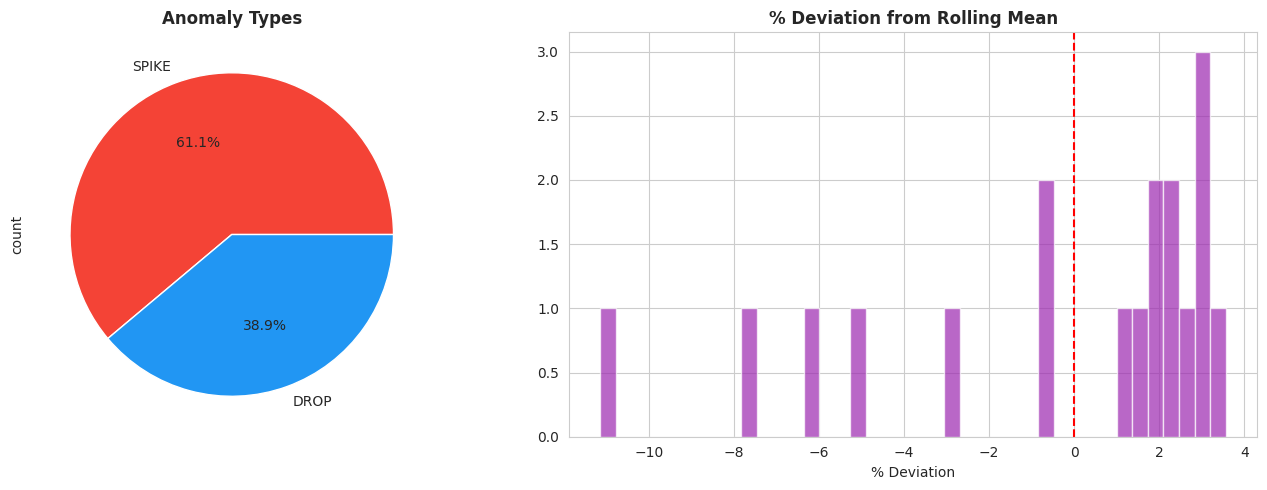

In [16]:
high_conf = df[df['anom_score'] >= 2].copy()

# Spike vs Drop
high_conf['type'] = np.where(
    high_conf['consumption'] > high_conf['rolling_mean'], 'SPIKE', 'DROP'
)
print("=== Anomaly Types ===")
print(high_conf['type'].value_counts())

# Magnitude
high_conf['pct_deviation'] = 100 * (high_conf['consumption'] - high_conf['rolling_mean']) / high_conf['rolling_mean']
print(f"\nDeviation stats:")
print(high_conf['pct_deviation'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type distribution
high_conf['type'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%', colors=['#F44336','#2196F3'])
axes[0].set_title('Anomaly Types', fontweight='bold')

# Deviation histogram
axes[1].hist(high_conf['pct_deviation'].dropna(), bins=40, color='#9C27B0', alpha=0.7, edgecolor='white')
axes[1].set_title('% Deviation from Rolling Mean', fontweight='bold')
axes[1].set_xlabel('% Deviation')
axes[1].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

## 12. COVID-19 Impact Check (2020)
Major real-world event — does the data show structural change?

=== Yearly Statistics ===
              mean          std    min    max
year                                         
2015  10412.000000   397.840420  10005  10800
2016   9552.723762  1610.480291   5593  15105
2017   9521.906546  1438.722023   5854  14273
2018   9791.894052  1633.743870   6348  14062
2019   9482.383718  1605.762376   5455  14542
2020   8916.402045  1311.843901   5341  12388
2021   9669.531803  1678.492436   6450  14267


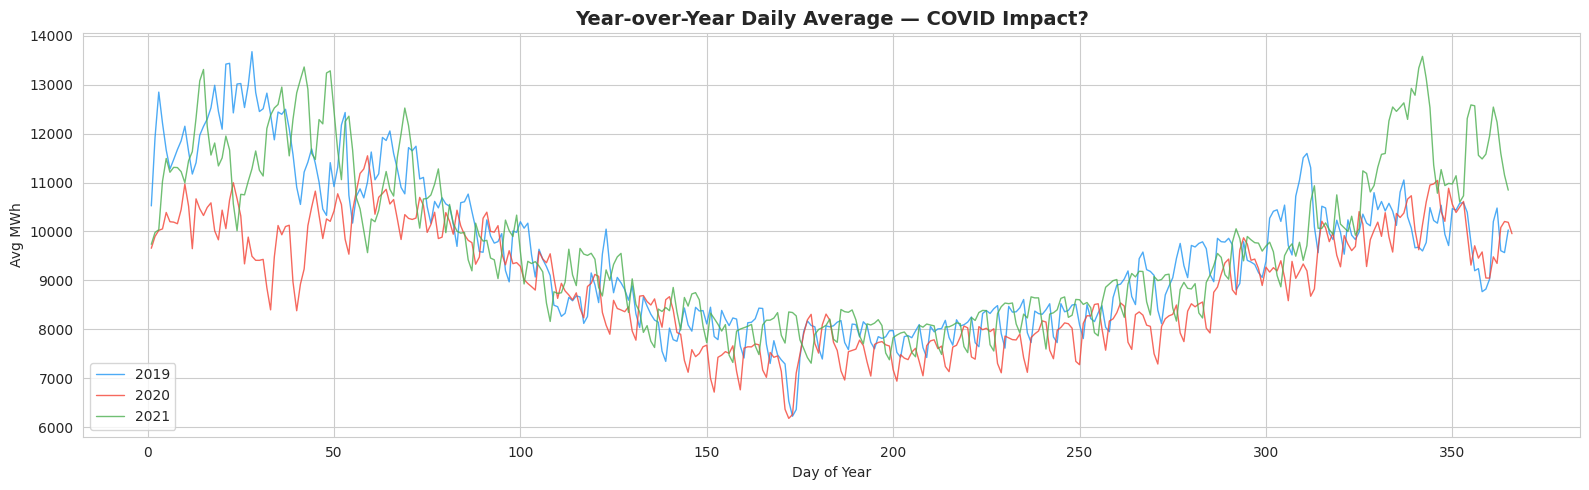

In [17]:
yearly_stats = df.groupby('year')['consumption'].agg(['mean', 'std', 'min', 'max'])
print("=== Yearly Statistics ===")
print(yearly_stats)

fig, ax = plt.subplots(figsize=(16, 5))
for yr, color in zip([2019, 2020, 2021], ['#2196F3', '#F44336', '#4CAF50']):
    sub = df[df['year'] == yr].copy()
    sub['day_of_year'] = sub['start'].dt.dayofyear
    daily = sub.groupby('day_of_year')['consumption'].mean()
    ax.plot(daily.index, daily.values, linewidth=1, label=str(yr), color=color, alpha=0.8)
ax.set_title('Year-over-Year Daily Average — COVID Impact?', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Year')
ax.set_ylabel('Avg MWh')
ax.legend()
plt.tight_layout()
plt.show()

## 📊 Feasibility Summary & Recommendations

### What the data tells us:
1. **Strong seasonality** — clear hourly, daily, and monthly patterns exist
2. **Natural outliers are rare** — data is fairly clean (IQR outliers are few %)
3. **Context matters hugely** — same value can be normal or anomalous depending on hour/day
4. **Timestamp irregularities** exist (non-hourly gaps) — these themselves are data quality anomalies
5. **Year-over-year trends** show structural shifts (possibly COVID-related)

### What's PRACTICAL to implement (ranked by impact):

| # | Method | Feasibility | Impact | Why |
|---|--------|------------|--------|-----|
| 1 | **Context-Aware Z-Score** | ✅ Easy | 🔥 High | Catches anomalies others miss; domain-relevant |
| 2 | **Isolation Forest** | ✅ Easy | 🔥 High | Multi-feature; no labels needed |
| 3 | **Rolling Statistics** | ✅ Easy | 🟡 Medium | Good for trend shifts |
| 4 | **Ensemble Scoring** | ✅ Easy | 🔥 High | Combine above 3 = reliable |
| 5 | **Anomaly Classification** (spike/drop/pattern-shift) | ✅ Easy | 🟡 Medium | Low-hanging fruit from ensemble |
| 6 | **LSTM Autoencoder** | 🟡 Medium | 🟡 Medium | Only 1 feature; limited upside over simpler methods |
| 7 | **Synthetic Anomaly Injection** | ✅ Easy | 🔥 High | Great for validation/demo |
| 8 | **Real-time Simulation** | 🟡 Medium | 🟡 Medium | Cool demo but not core value |
| 9 | **Root Cause (SHAP)** | ⚠️ Hard | 🟡 Medium | Only 1 consumption column — limited explainability |
| 10 | **Future Anomaly Prediction** | ⚠️ Hard | 🟡 Low | Needs good forecasting model first |

### ❌ What's NOT practical:
- **Root Cause Analysis with SHAP** — Only 1 real feature (consumption). No weather, pricing, or event data to explain WHY.
- **LSTM Autoencoder** — With a single univariate series, it won't dramatically beat Isolation Forest + Context Z-scores. Overkill.
- **Anomaly Prediction** — Requires a solid forecasting model as prerequisite; separate project.
- **One-Class SVM** — Very slow on 53K rows with no real advantage over Isolation Forest.

### ✅ My Recommendation — Build These:
1. **Context-Aware Z-Score** (statistical backbone)
2. **Isolation Forest** (ML backbone)  
3. **Ensemble Scoring** (combine both + rolling stats)
4. **Synthetic Anomaly Injection** (for validation — proves your system works)
5. **Anomaly Classification** (spike/drop/shift — comes free from ensemble)
6. **Dashboard visualization** (plotly — makes everything look impressive)